<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-III/blob/main/Introducci%C3%B3n_DL/RedesNeuronales_Clasificacion_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Clasificación de Flores Iris con Redes Neuronales


## 📥 Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


# Importamos las librerias de redes neuronales con sus principales métodos
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
# Cargar el conjunto de datos de iris
iris = sns.load_dataset('iris')

iris


## 🔍 Exploración rápida del dataset

In [ ]:
!pip install skimpy -q

In [ ]:
from skimpy import skim
iris.species= iris.species.astype("category")
skim(iris)

## 🎯 Separación de features (X) y target (y)

In [ ]:
# Separar las características (X) y las etiquetas (y)
X = iris.drop('species', axis=1)
y = iris['species']
X.head()


In [ ]:
y.head()

## 🏷️ Codificación de etiquetas

In [ ]:
from sklearn.preprocessing import LabelEncoder


# Crear el codificador de etiquetas
label_encoder = LabelEncoder()

# Aplicar el codificador a la variable objetivo "species"
y = label_encoder.fit_transform(y)

In [ ]:
y

## 🧹 Escalado de features

In [ ]:
# las redes neuronales son muy sensibles a datos no escalados
scaler_labels = StandardScaler()
X= scaler_labels.fit_transform(X)

## ✂️ Train / Test split

In [ ]:
#Separo los datos de "train" en entrenamiento y prueba "test" para probar los algoritmos
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 🧠 Arquitectura del modelo

In [ ]:
#Defino la función neuronal
def define_model():

    keras.backend.clear_session()
    # se eliminan todos los modelos y operaciones creados en la sesión actual, libera memoria y permita una construcción en limpio
    model = keras.models.Sequential()
    # se utiliza para crear un modelo secuencial en deep learning. Un modelo secuencial es una pila de capas donde la salida de una capa es la entrada de la siguiente capa.

     # 2 capas ocultas con función de activación relu
    model.add(keras.layers.Dense(8, input_dim=4, kernel_initializer='normal', activation='relu'))
    model.add(keras.layers.Dense(4, kernel_initializer='normal', activation='relu'))
    #capa de salida
    model.add(keras.layers.Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

    # kernel_initializer='normal', los pesos de las capas densas se inicializan aleatoriamente según la distribución normal.
    # La función de pérdida (loss function) se utiliza durante el entrenamiento para optimizar los pesos del modelo
    # El optimizador "adam" se utiliza para ajustar los pesos del modelo durante el entrenamiento.
    # Las métricas de evaluación accuracy para monitorear durante el entrenamiento


loss='sparse_categorical_crossentropy'. Importante — esto implica que tus etiquetas y deben ser enteros (0, 1, 2), NO one-hot encoded. Si tus labels estuvieran en one-hot, tendrías que usar categorical_crossentropy en su lugar

Si vemos un ejemplo similar, podemos observar  la estructura de una red neuronal multicapa (una capa de entrada con cinco nodos, dos capas ocultas de cuatro y tres nodos respectivamente, y una capa de salida de dos nodos: 5-4-3-2).

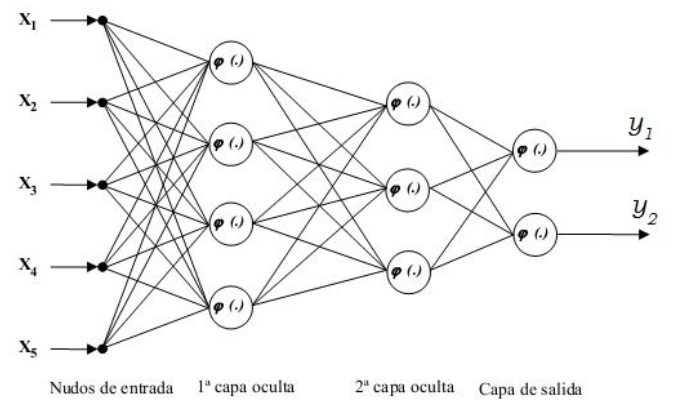

Funciones de activación:

ReLU (Rectified Linear Unit): La función ReLU asigna cero a todos los valores negativos y mantiene los valores positivos sin cambios. Es ampliamente utilizada debido a su eficiencia de cálculo y su capacidad para introducir no linealidades en el modelo.

Sigmoid: La función sigmoid (o logística) toma cualquier valor real y lo comprime en un rango entre 0 y 1. Se utiliza comúnmente en problemas de clasificación binaria para obtener probabilidades de clasificación.

Tanh (Tangente hiperbólica): La función tanh es similar a la sigmoid, pero su rango es entre -1 y 1. También se utiliza en problemas de clasificación y tiene la propiedad de ser simétrica alrededor del origen.

Softmax: La función softmax se utiliza en problemas de clasificación multiclase para obtener probabilidades de clasificación para cada clase. Toma un vector de valores reales y los normaliza para sumar 1, lo que permite interpretar los valores resultantes como probabilidades.

Linear (Lineal): La función lineal simplemente pasa los valores de entrada sin realizar ninguna transformación no lineal. Se utiliza en casos donde se desea una salida lineal sin aplicar ninguna función de activación específica.

## 🏋️ Entrenamiento

In [ ]:
model = define_model()

#Early es un buen metodo de regularizacion, en patience aplicamos un 30 para que al menos tengan que pasar 30 epoch antes de hacer una parada.
early = keras.callbacks.EarlyStopping(patience=30, monitor='val_loss', restore_best_weights=True)
history = model.fit(epochs=300, batch_size=32, x=x_train, y=y_train, validation_data=(x_test, y_test), callbacks=[early])


## 📊 Evaluación del modelo

In [ ]:
# EVALUACIÓN DEL MODELO

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Pérdida')
    plt.plot(hist['epoch'], hist['loss'],
           label='Pérdida entrenamiento')
    plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Pérdida validación')
    plt.ylim([0,2])
    plt.legend()

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Exactitud')
    plt.plot(hist['epoch'], hist['accuracy'],
           label='Exactitud entrenamiento')
    plt.plot(hist['epoch'], hist['val_accuracy'],
           label = 'Exactitud Validación')
    plt.ylim([0,1])
    plt.legend()
    plt.show()


plot_history(history)

# una buena red es aquella donde la función de perdida en test y train es baja

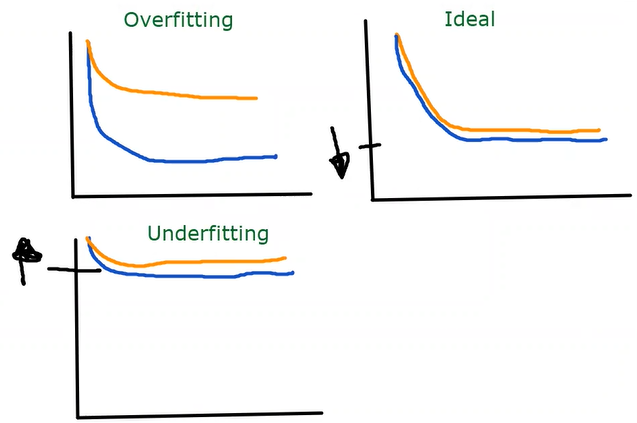

## 🔮 Predicciones

In [ ]:
# Predicciones sobre TEST (datos que el modelo no vio en el entrenamiento)
y_pred = model.predict(x_test)
y_pred_c = np.argmax(y_pred, axis=1)

In [ ]:
y_pred

In [ ]:
y_pred_c

## 📋 Reporte de clasificación

In [ ]:
from sklearn.metrics import classification_report

# Reporte de clasificación sobre TEST: así medimos generalización, no memorización
classification_summary = classification_report(y_test, y_pred_c)
print(classification_summary)

## 🔥 Matriz de confusión

In [ ]:
cm = confusion_matrix(y_test, y_pred_c)

In [ ]:
sns.heatmap(cm,annot=True)
plt.savefig('h.png')